In [2]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import glob
import os
import shutil
import random
import pydicom
import pandas as pd
import math
from PIL import Image

In [3]:
# For each patient
    # For each acquisition
        # Get all S2 data in one folder

        # Read temperatureData dicom series as SITK
        # Read anatomicalData dicom series as SITK
        # Use pydicom to read temperatureDataS2

        # Create resampler 

        # Acquire laser location from csv
        # Create transformation matrix and transform laser location

        # Crop and save segmentation

In [4]:
def getS2(source_folder):
    destination_folder = source_folder.replace("temperatureData", "temperatureDataS2")
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    for root, dirs, files in os.walk(source_folder):
        for file in files:
            if 'S2' in file:
                source_path = os.path.join(root, file)
                destination_path = os.path.join(destination_folder, file)
                shutil.copy(source_path, destination_path)


In [5]:
# Load in dicom series as SITK image
def SITK_loader(filepath):
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(filepath)
    reader.SetFileNames(dicom_names)
    sitk_img = reader.Execute()
    
    return sitk_img

In [6]:
# Resampler from anatomicalSeg to temperatureDataS2

def create_resampler(source_sitk, target_sitk):

    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(target_sitk)
    resampler.SetDefaultPixelValue(source_sitk.GetPixelIDValue())
    resampler.SetSize((128, 128, 1))
    resampler.SetOutputSpacing((2.0,2.0,1.0))
    resampler.SetOutputOrigin(target_sitk.GetOrigin())
    resampler.SetOutputDirection(target_sitk.GetDirection())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampled_img = resampler.Execute(source_sitk)
    resampled_img_array = sitk.GetArrayFromImage(resampled_img[:, :,0])

    # Combine GM and WM labels
    resampled_img_array[resampled_img_array == 3] = 2

    return resampled_img_array, resampled_img

In [7]:
# Obtain laser location from csv file
def get_laser(filepath):
    
    # read the CSV file
    df = pd.read_csv(filepath)
    
    #Find the probe location from pandas dataframe 
    laser_loc_x = float(df.iloc[10][1])
    laser_loc_y = float(df.iloc[11][1])
    laser_loc_z = float(df.iloc[12][1])
    
    return [laser_loc_x, laser_loc_y, laser_loc_z]

In [8]:
# # Project laser from csv file onto temperatureS2

# def project_laser(temp_dir, laser_loc):
#     # Get random dcm file from S2 temp directory
#     files = os.listdir(temp_dir)
#     random_file = random.choice(files)
#     S2_file = os.path.join(temp_dir, random_file)

#     # Create transformation matrix
#     ds = pydicom.dcmread(S2_file)
#     laser_point = np.append(np.array(laser_loc), 1)
#     Sxyz = ds[0x0020,0x0032].value
#     Xxyz = ds[0x0020,0x0037].value
#     Yxyz = ds[0x0020,0x0037].value

#     Xxyz = np.array(Xxyz[0:3])
#     Yxyz = np.array(Yxyz[3:6])

#     itri = ds[0x0028,0x0030].value
#     jtri = ds[0x0028,0x0030].value

#     # print("point:", laser_point[0:3])
#     # print("Sxyz:",Sxyz)
#     # print("Xxyz:",Xxyz)
#     # print("Yxyz:",Yxyz)
#     # print("itri:",2)

#     trans = np.array([[Xxyz[0]*2, Yxyz[0]*2, 0, Sxyz[0]],
#                     [Xxyz[1]*2, Yxyz[1]*2, 0, Sxyz[1]],
#                     [Xxyz[2]*2, Yxyz[2]*2, 0, Sxyz[2]],
#                     [0, 0, 0, 1]]  )


#     trans_mat = np.linalg.pinv(trans)
#     new_laser = np.dot(trans_mat,laser_point)

#     new_laser = new_laser[:-1]

#     return new_laser

In [9]:
def project_laser(resampled_img, laser_loc):

    return resampled_img.TransformPhysicalPointToContinuousIndex((laser_loc))
    

In [18]:
# Crop image to 51x51 using specified centre location
def Crop(center_point, img_array):
    left = (center_point[0] - 25.5)
    right = (center_point[0] + 25.5)
    top = (center_point[1] + 25.5)
    bottom = (center_point[1] - 25.5)

    # Account for even center so that laser is always in the middle pixel
    if (left % 2) == 0 or(right % 2) == 0:
        left -= 1
        right += 1
    if (top % 2) == 0 or(bottom % 2) == 0:
        top += 1
        bottom -= 1

    # Round decimal to int
    left = round(left)
    right = round(right)
    top = round(top)
    bottom = round(bottom)

    # Define the region to crop
    region = [left, top, 0]  # Start index (left, top) at slice 0
    size = [right - left, bottom - top, 0]  # Size of the cropped region

    # Crop the image
    cropped_img = img_array[left:right, bottom:top]

    return cropped_img



In [19]:
# Save segmentation array as png

def saveImage(img_array, save_dir):
    
    # Normalize pixel values to 0-255
    segmentation_cropped_normalized = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array)) * 255
    segmentation_cropped_normalized = segmentation_cropped_normalized.astype(np.uint8)

    # Convert NumPy array to PIL Image
    segmentation_cropped_image = Image.fromarray(segmentation_cropped_normalized)
    print(segmentation_cropped_image.size)

    # Save the cropped image as PNG
    segmentation_cropped_image.save(save_dir)

In [20]:

root_directory = "E:\Documents\\MTLE"
save_png_dir = "E:\Documents\MRgLITT\data\\500J\original\segmentationData"
target_name = (os.path.join(root_directory, '**','**', ))
acquisitions = glob.glob(target_name)

num = len(acquisitions)
for ac in acquisitions:

    print("Currently working on:", ac)

    # Get CaseNotes Csv File
    caseNotes_dir = os.path.join(ac, "caseNotes.csv")

    # Create seg SITK image
    sitkSeg_dir = os.path.join(ac, "anatomicalSeg")
    seg_sitk = SITK_loader(sitkSeg_dir)

    # copy only S2 dcm to new folder
    all_temp = os.path.join(ac, "temperatureData")
    getS2(all_temp)

    # Create S2 SITK image
    sitkTemp_dir = os.path.join(ac, "temperatureDataS2")
    temp_sitk = SITK_loader(sitkTemp_dir)

    # Create resampled segmentation image
    resampled_segmentation, resampled_sitk = create_resampler(seg_sitk, temp_sitk)

    # Get laser location of current acquisition
    laser_loc = get_laser(caseNotes_dir)
    
    # Get Projected Laser
    projected_laser = project_laser(resampled_sitk, laser_loc)

    # Crop to 51x51 with center point as laser location
    cropped_seg = Crop(projected_laser, resampled_segmentation)
    # cropped_seg = Crop([63.5,63.5], resampled_segmentation)

    # # Save segmentationa as PNG
    # print(save_png_dir+ ac[ac.find("MTLE") + len("MTLE"):])
    save_dir = os.path.join(save_png_dir, os.path.basename(ac)) + '-S2CroppedSeg.png'
    saveImage(cropped_seg,save_dir)

    
        



Currently working on: E:\Documents\MTLE\LP-0001\LP-0001-01-01-01
(51, 51)
Currently working on: E:\Documents\MTLE\LP-0001\LP-0001-01-01-02
(51, 51)
Currently working on: E:\Documents\MTLE\LP-0002\LP-0002-01-01-01
(51, 51)
Currently working on: E:\Documents\MTLE\LP-0008\LP-0008-01-01-01
(51, 51)


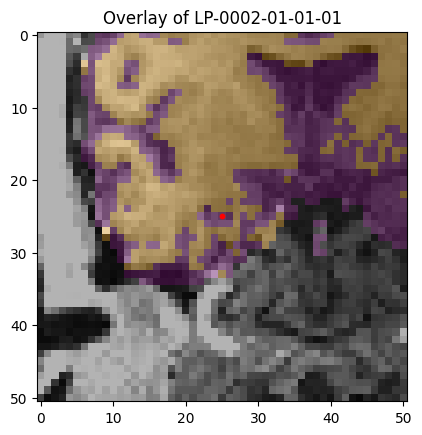

In [22]:
## Tester - plot anatomicalProbesEye png + segmentationData png
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
colors_1=["white", "darkmagenta","blue","green","yellow","orange","red", "black"]
nodes_1 = [0.0, 0.04, 0.078, 0.14, 0.17, 0.23, 0.34, 1.0]
Monteris_cmap = LinearSegmentedColormap.from_list("mycmap", list(zip(nodes_1, colors_1)))

colors = ['black', 'purple', 'orange']
integer_values = [0, 1, 2]
labels = ['CSF', 'Brain Matter']

# Create the custom colormap
custom_colormap = ListedColormap(colors)

# probes = Image.open("E:\Documents\MRgLITT\data\\500J\\first_acquisition\\temperatureData\LP-0002-01-01-01-089.S2Cropped.png")
# probes = Image.open("E:\Documents\MRgLITT\data\\500J\\first_acquisition\\\LP-0002-01-01-01-065.S2Cropped.png")
probes = Image.open("E:\Documents\MRgLITT\data\\500J\\first_acquisition\\anatomicalProbesEye\\\LP-0002-01-01-01-S2Cropped.png")

seg = Image.open("E:\Documents\MRgLITT\data\\500J\original\segmentationData\LP-0002-01-01-01-S2CroppedSeg.png")

plt.title("Overlay of LP-0002-01-01-01")
plt.imshow(probes, cmap = 'hot')
plt.imshow(seg,cmap = custom_colormap, vmin=0, vmax=255,alpha = 0.3)
plt.scatter(25,25, color = 'red', s=10)
